In [2]:
import pickle 
import logging
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

import tigramite.data_processing as td
import tigramite.plotting as tp
from tigramite.causal_effects import CausalEffects
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.parcorr_wls import ParCorrWLS

In [3]:
logging.basicConfig(
    level=logging.INFO,              
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    stream=sys.stdout
)
logger = logging.getLogger(__name__)
logging.getLogger("graph_validation_CI").setLevel(logging.CRITICAL)


In [4]:
def load_ts_df(
    file_path: Path, 
) -> pd.DataFrame:
    """Load q/climate ts df from LamaH-CE, and change index to datetime."""

    df = pd.read_csv(filepath_or_buffer=file_path, header=0, sep=";")

    df_date_index = (df
    .assign(date=pd.to_datetime(df.rename(columns={"DD": "day", "MM": "month", "YYYY": "year"})[["year", "month", "day"]]))
    .drop(columns=["DD", "MM", "YYYY"])
    .set_index("date")
    )
    return df_date_index

def calculate_snowmelt(
        climate_ts_df: pd.DataFrame
) -> pd.DataFrame: 
    """Calculate snowmelt as depletion of SWE from t-1 to t in basin."""

    snow_ts = climate_ts_df.swe

    # First day cannot have depletion.
    snow_depletion = [np.nan]
    prev = snow_ts.iloc[0]

    for day in range(1, len(snow_ts)):

        current = snow_ts.iloc[day]

        # Calculate delta swe from t-1 to t, if positive denote, else 0.
        depletion = prev - current

        if depletion > 0: 

            snow_depletion.append(depletion)

        else: 

            snow_depletion.append(0)

        prev = current

    # Sanity check. 
    logger.info(
        "Calculated snowmelt:"
        f"\n min  : {np.nanmin(snow_depletion)}"
        f"\n max  : {np.nanmax(snow_depletion)}"
        f"\n mean : {np.nanmean(snow_depletion)}"
    )

    # Add to df.
    climate_ts_df["snowmelt"] = snow_depletion

    return climate_ts_df


def construct_vars_tg(
        lamah_ce_path: Path, 
        basin_id: int
) -> pd.DataFrame: 

    # Load df's. 
    climate_ts_path = lamah_ce_path / f"B_basins_intermediate_all/2_timeseries/daily/ID_{basin_id}.csv"
    q_ts_path = lamah_ce_path / f"D_gauges/2_timeseries/daily/ID_{basin_id}.csv"

    climate_ts_df = load_ts_df(climate_ts_path) 
    q_ts_df = load_ts_df(q_ts_path) 
    logger.info(f"Loaded data from:\n{climate_ts_path}\n{q_ts_path}")

    climate_ts_df = calculate_snowmelt(climate_ts_df=climate_ts_df)

    # Select only relvant climate vars.
    climate_vars_df = climate_ts_df.loc[:, ["2m_temp_mean", "prec", "total_et", "volsw_123", "snowmelt"]]

    # Add discharge
    vars_df = pd.concat([climate_vars_df, q_ts_df["qobs"]], axis=1)

    # Rename for easier access.
    vars_df.columns = ["TEMP", "P", "ET", "SM", "SNO", "Q"]

    # Remove missing.
    vars_df = vars_df.dropna()

    if vars_df.isna().any(axis=None): 
        logger.error("vars_df still conains NA.")
        raise

    # Convert to tigramite form. 
    vars_tg = td.DataFrame(data=vars_df.to_numpy(), var_names=vars_df.columns)

    logger.info(f"Variable names in vars_tg: {vars_tg.var_names}")

    return vars_tg, vars_df


## Data

In [ ]:
lamah_ce_path = Path("/home/tripleuuu/Nextcloud/coding/causal_inference/snow_causal_inference/data/raw_data/2_LamaH-CE_daily")
#lamah_ce_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily")

basin_id = 802

experiment_dir = Path("../experiments") / str(basin_id)
experiment_dir.mkdir(exist_ok=True)

climate_ts_802_path = lamah_ce_path / f"B_basins_intermediate_all/2_timeseries/daily/ID_{basin_id}.csv"
q_ts_802_path = lamah_ce_path / f"D_gauges/2_timeseries/daily/ID_{basin_id}.csv"

FileNotFoundError: [Errno 2] No such file or directory: '/home/wuhlmann/CS/causal_inference/snow_causal_inference/experiments/802'

In [ ]:
climate_ts_802_df = load_ts_df(climate_ts_802_path) 
q_ts_802_df = load_ts_df(q_ts_802_path) 

In [ ]:
vars_tg, vars_df = construct_vars_tg(lamah_ce_path=lamah_ce_path, basin_id=802)

2026-09-14 15:13:20 - INFO - Loaded data from:
/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily/ID_802.csv
/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/2_timeseries/daily/ID_802.csv


2026-09-14 15:13:20 - INFO - Calculated snowmelt:
 min  : 0.0
 max  : 32.19999999999999
 mean : 1.9031755950291371
2026-09-14 15:13:20 - INFO - Variable names in vars_tg: Index(['TEMP', 'P', 'ET', 'SM', 'SNO', 'Q'], dtype='str')


Check for seasons with no snowmelt.

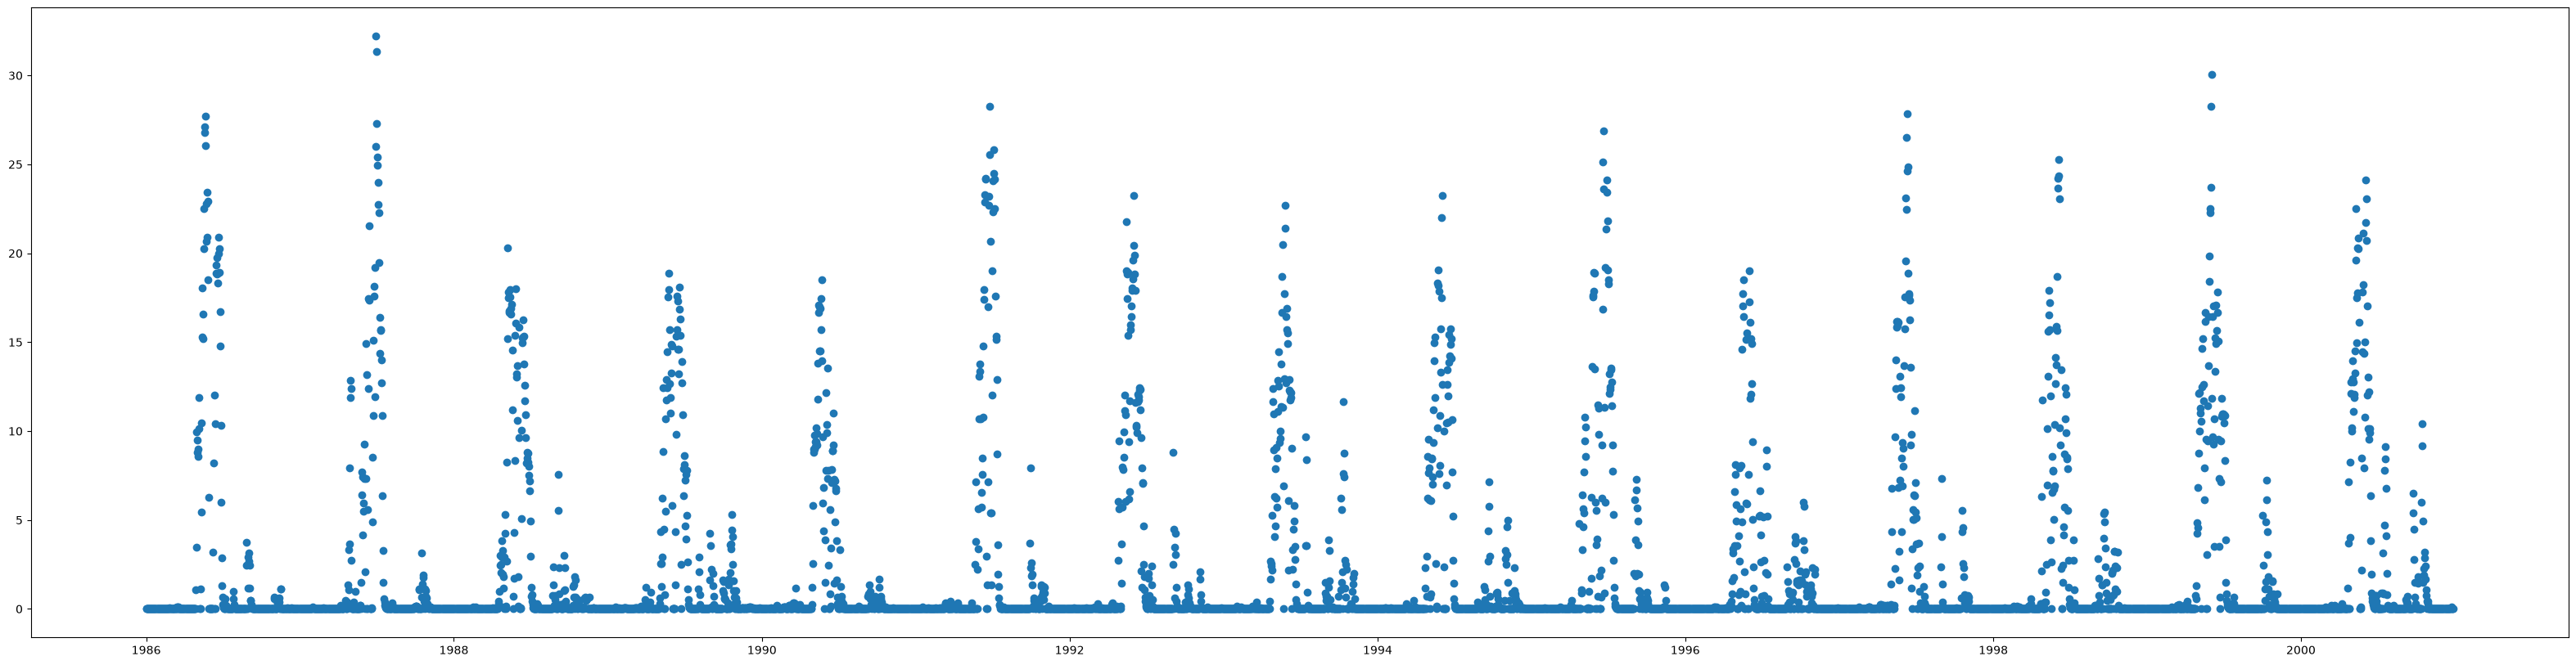

In [ ]:
fig, ax = plt.subplots(figsize=(40,10))

sliced_df = vars_df.iloc[365*5:365*20,:]

ax.scatter(x=sliced_df.index, y=sliced_df.SNO)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter(
    x=vars_df.index,
    y=vars_df.SNO,
    mode='markers', # 'markers', 'lines' oder 'lines+markers'
    name='Messreihe 1'
))

fig.update_layout(title="Snowmelt 1982-2017")
fig.show()

## 1. Graph-Validation 

Check that the distribution is markov to the graph. 

#### First draft of graph

In [ ]:
# define tigramite graph and plot it 
draft = 1

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# variables are basinwise aggregates 

# temp 
graph[0, 0, 1] = "-->" # self causation
graph[0, 1, 0] = "-->" # impact on prec, if it gets hotter more water can be bound in air --> higher prec
graph[1, 0, 0] = "<--" # reverse
graph[0, 2, 0] = "-->" # higher temp, more et
graph[2, 0, 0] = "<--" # reverse
graph[0, 4, 0] = "-->" # impact on snowmelt
graph[4, 0, 0] = "<--" # reverse

# prec 
graph[1, 1, 1] = "-->" # self causation
graph[1, 2, 0] = "-->" # impact on et, instant
graph[2, 1, 0] = "<--" # reverse
graph[1, 3, 0] = "-->" # impact on sm, instant where water hits the ground it infiltrates
graph[3, 1, 0] = "<--" # reverse
graph[1, 5, 0] = "-->" # impact on q, instant
graph[5, 1, 0] = "<--" # reverse

# et 
graph[2, 2, 1] = "-->" # self causation
graph[2, 0, 1] = "-->" # impact on temp, lagged as basinwise it takes some time to cool it
graph[2, 1, 1] = "-->" # lagged impact on prec
graph[2, 3, 0] = "-->" # impact on sm, lagged because puddles get et'd before soil
graph[3, 2, 0] = "<--" # impact on sm, instant over basin
graph[2, 5, 0] = "-->" # impact on q
graph[5, 2, 0] = "<--" # reverse

# sm  
graph[3, 3, 1] = "-->" # self causation
graph[3, 2, 1] = "-->" # impact on et, lagged because soil moistru
graph[3, 5, 0] = "-->" # impact on q
graph[5, 3, 0] = "<--" # reverse

# snowmelt 
graph[4, 4, 1] = "-->" # self causation
graph[4, 2, 0] = "-->" # impact on et, more liquid water --> more et
graph[2, 4, 0] = "<--" # reverse
graph[4, 3, 0] = "-->" # impact on sm, more liquid water can infiltrate
graph[3, 4, 0] = "<--" # reverse
graph[4, 5, 1] = "-->" # impact on qobs 
#graph[5, 4, 0] = "<--" # reverse

# q
graph[5, 5, 1] = "-->" # self causation


(<Figure size 640x480 with 1 Axes>, <Axes: >)

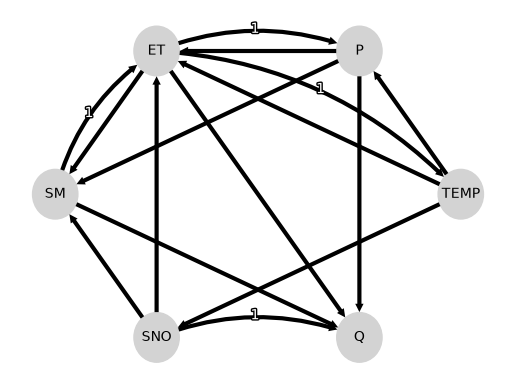

In [ ]:
tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns,
    arrow_linewidth=3
)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

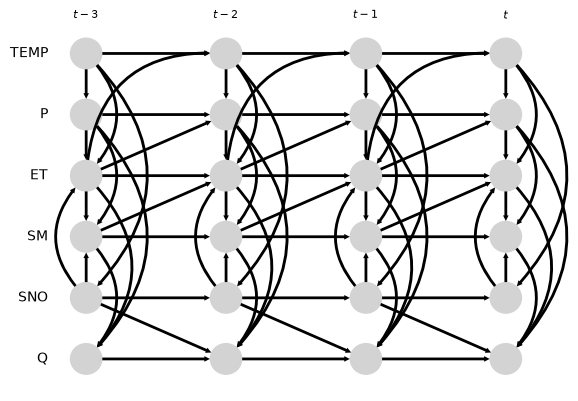

In [ ]:
tp.plot_time_series_graph(graph=graph, var_names=vars_df.columns, curved_radius=0.5, arrow_linewidth=2)

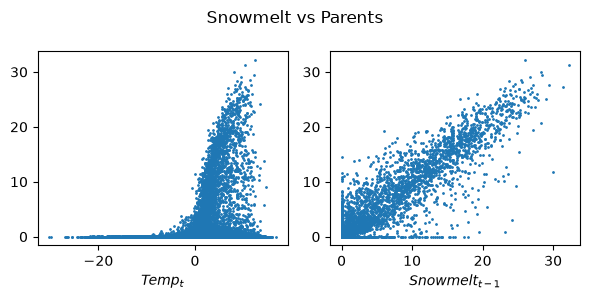

In [ ]:
# Plot snow vs parents
fig, axs = plt.subplots(1, 2, figsize=(6,3))

size = 1

axs[0].scatter(x=vars_df.TEMP, y=vars_df.SNO, s=size)
axs[0].set_xlabel("$Temp_t$")
axs[1].scatter(x=vars_df.SNO[:-1], y=vars_df.SNO[1:], s=size)
axs[1].set_xlabel("$Snowmelt_{t-1}$")

fig.suptitle("Snowmelt vs Parents")
#fig.supylabel("$Snowmelt_t$", rotation=0)
plt.tight_layout()

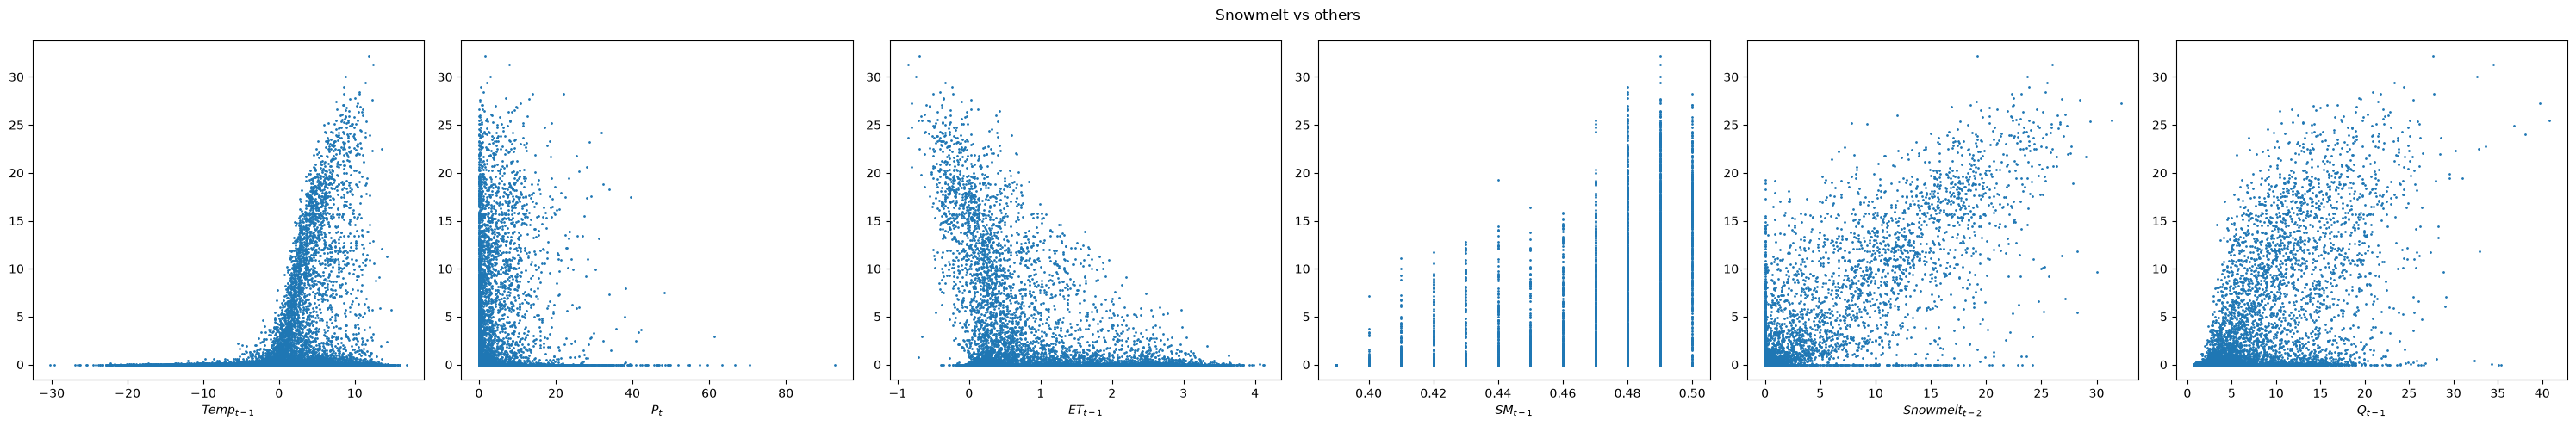

In [ ]:
# Plot snow vs others 

fig, axs = plt.subplots(1, 6, figsize=(30,5))

axs[0].scatter(x=vars_df.TEMP[:-1], y=vars_df.SNO[1:], s=size)
axs[0].set_xlabel("$Temp_{t-1}$")
axs[1].scatter(x=vars_df.P, y=vars_df.SNO, s=size)
axs[1].set_xlabel("$P_t$")
axs[2].scatter(x=vars_df.ET[:-1], y=vars_df.SNO[1:], s=size)
axs[2].set_xlabel("$ET_{t-1}$")
axs[3].scatter(x=vars_df.SM[:-1], y=vars_df.SNO[1:], s=size)
axs[3].set_xlabel("$SM_{t-1}$")
axs[4].scatter(x=vars_df.SNO[:-2], y=vars_df.SNO[2:], s=size)
axs[4].set_xlabel("$Snowmelt_{t-2}$")
axs[5].scatter(x=vars_df.Q[:-1], y=vars_df.SNO[1:], s=size)
axs[5].set_xlabel("$Q_{t-1}$")


fig.suptitle("Snowmelt vs others")
#fig.supylabel("$Snowmelt_t$")
plt.tight_layout()

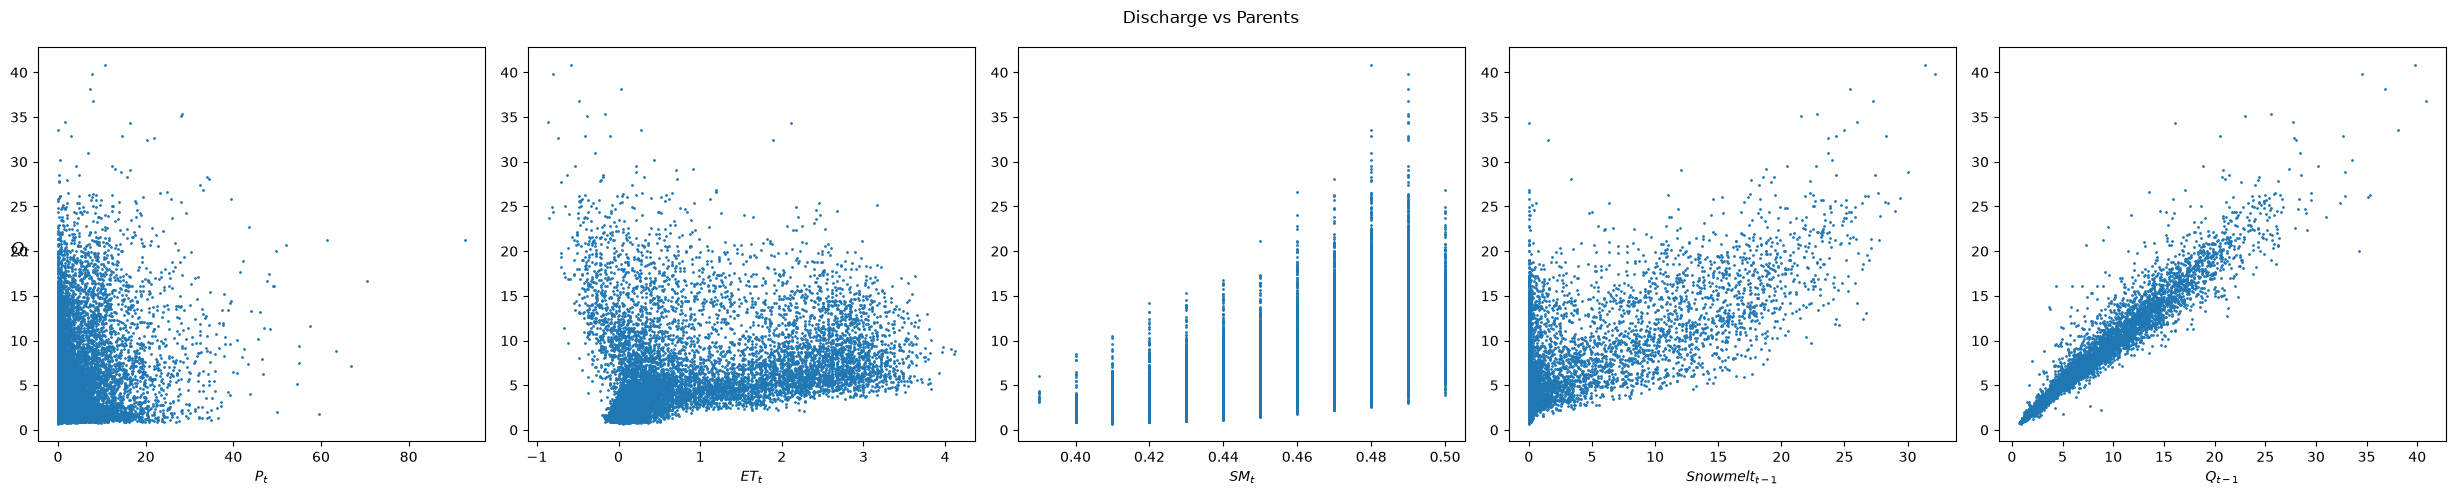

In [ ]:
# plot qobs vs parents
fig, axs = plt.subplots(1, 5, figsize=(25,5))

axs[0].scatter(x=vars_df.P, y=vars_df.Q, s=size)
axs[0].set_xlabel("$P_t$")
axs[1].scatter(x=vars_df.ET, y=vars_df.Q, s=size)
axs[1].set_xlabel("$ET_t$")
axs[2].scatter(x=vars_df.SM, y=vars_df.Q, s=size)
axs[2].set_xlabel("$SM_t$")
axs[3].scatter(x=vars_df.SNO[:-1], y=vars_df.Q[1:], s=size)
axs[3].set_xlabel("$Snowmelt_{t-1}$")
axs[4].scatter(x=vars_df.Q[:-1], y=vars_df.Q[1:], s=size)
axs[4].set_xlabel("$Q_{t-1}$")

fig.suptitle("Discharge vs Parents")
fig.supylabel("$Q_t$", rotation=0)
plt.tight_layout()


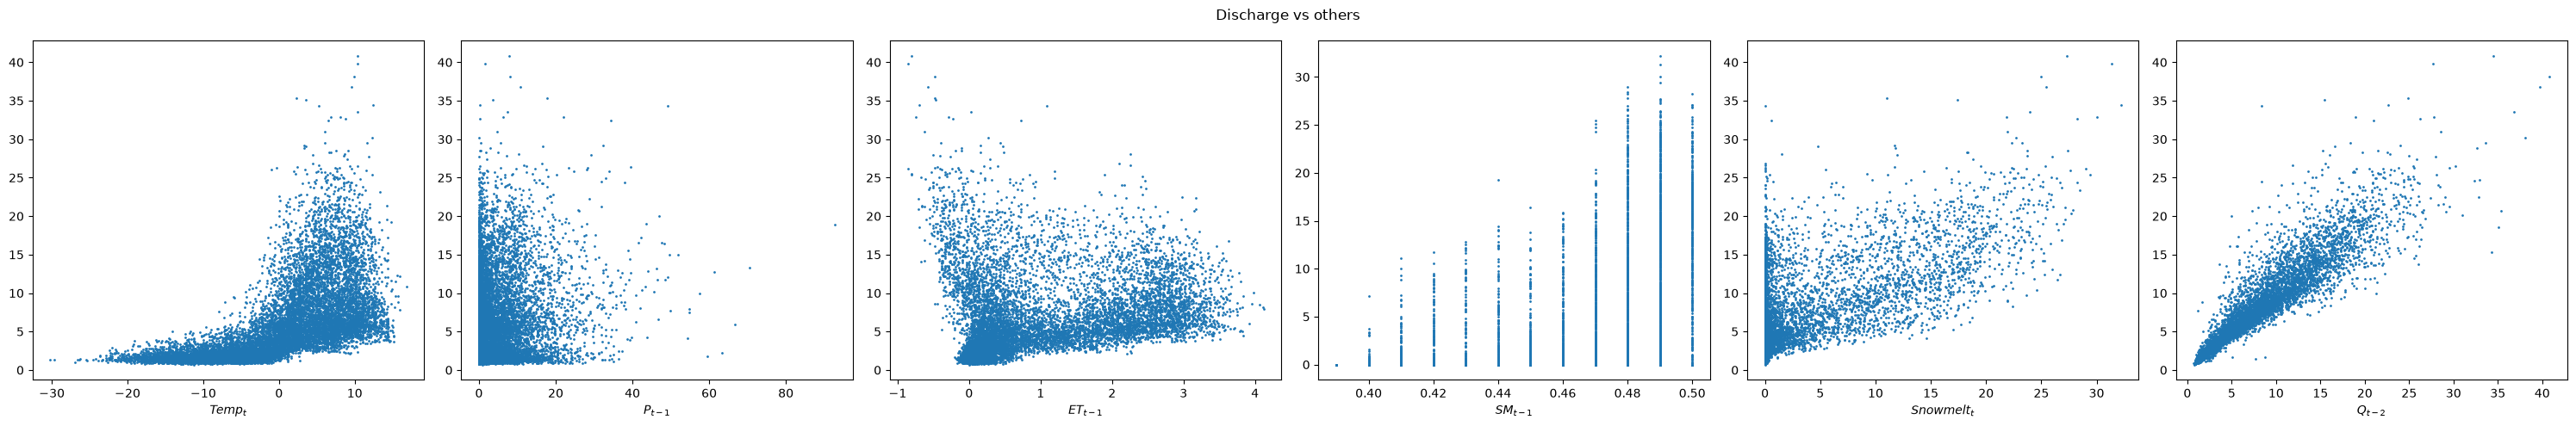

In [ ]:
# Plot discharge vs others 

fig, axs = plt.subplots(1, 6, figsize=(30,5))

axs[0].scatter(x=vars_df.TEMP, y=vars_df.Q, s=size)
axs[0].set_xlabel("$Temp_t$")
axs[1].scatter(x=vars_df.P[:-1], y=vars_df.Q[1:], s=size)
axs[1].set_xlabel("$P_{t-1}$")
axs[2].scatter(x=vars_df.ET[:-1], y=vars_df.Q[1:], s=size)
axs[2].set_xlabel("$ET_{t-1}$")
axs[3].scatter(x=vars_df.SM[:-1], y=vars_df.SNO[1:], s=size)
axs[3].set_xlabel("$SM_{t-1}$")
axs[4].scatter(x=vars_df.SNO, y=vars_df.Q, s=size)
axs[4].set_xlabel("$Snowmelt_t$")
axs[5].scatter(x=vars_df.Q[:-2], y=vars_df.Q[2:], s=size)
axs[5].set_xlabel("$Q_{t-2}$")


fig.suptitle("Discharge vs others")
#fig.supylabel("$Snowmelt_t$")
plt.tight_layout()

Identify d-separation statement for all pairs of variables (incl. themselves)

snow t-1 --> qobs t (is there hidden confounding between these two?)

check snowmelt with all other varialbes 
qobs with all others 

investigate total_et

check collider: qobs t // sno t-2 | sno t-1
                qobs t // t t-1 | sno t-1

##### Formulate dict with configuration for CI tests. 

In [ ]:
CI_config_dict = {

    (4,0) : {
        "X_dict": {
            (0, -1) : ["CMIknn", [(0, -2), (2, -1)]],
            (1, 0)  : ["CMIknn", [(0, 0), (1, -1), (2, -1)]],
            (2, -1) : ["CMIknn", [(0, -1), (1, -1), (2, -2), (3, -2), (4, -1)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, -2) : ["CMIknn", [(0, -2), (4, -3)]],
            (5, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -1), (4, -2), (5, -2)]]
        },                   
        "Y_parents": [(0, 0), (4,-1)]
    },

    (5, 0) : {
        "X_dict": {
            (0, 0)  : ["CMIknn", [(0, -1), (2, -1)]],
            (1, -1) : ["CMIknn", [(0, -1), (1, -2), (2, -2)]],
            (2, -1) : ["CMIknn", [(0, -1), (1, -1), (2, -2), (3, -2), (4, -1)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, 0)  : ["CMIknn", [(0, -1), (4, -1)]],
            (5, -2) : ["CMIknn", [(1, -2), (2, -2), (3, -2), (4, -3), (5, -3)]]

        },
        "Y_parents" : [(1, 0), (2, 0), (3, 0), (4, -1), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [ ]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name.split("_")[-1]] = pickle.load(f)

In [ ]:
draft_results["50.pkl"]

{(4,
  0): {'X_dict': {(0, -1): ['CMIknn',
    [(0, -2), (2, -1)],
    (np.float64(0.006355697155026707), 0.001996007984031936, True)],
   (1, 0): ['CMIknn',
    [(0, 0), (1, -1), (2, -1)],
    (np.float64(0.03861843101824425), 0.001996007984031936, True)],
   (2, -1): ['CMIknn',
    [(0, -1), (1, -1), (2, -2), (3, -2), (4, -1)],
    (np.float64(0.008715081308340089), 0.001996007984031936, True)],
   (3, -1): ['CMIknn',
    [(1, -1), (2, -1), (3, -2), (4, -1)],
    (np.float64(0.0014003799030311015), 0.08582834331337326, False)],
   (4, -2): ['CMIknn',
    [(0, -2), (4, -3)],
    (np.float64(-0.0006670372293027249), 0.9281437125748503, False)],
   (5, -1): ['CMIknn',
    [(1, -1), (2, -1), (3, -1), (4, -2), (5, -2)],
    (np.float64(0.0012185197760237187),
     0.35129740518962077,
     False)]}, 'Y_parents': [(0, 0), (4, -1)]},
 (5,
  0): {'X_dict': {(0, 0): ['CMIknn',
    [(0, -1), (2, -1)],
    (np.float64(0.004168649225444021), 0.001996007984031936, True)],
   (1, -1): ['CMIknn',
 

#### Second draft of graph

In [ ]:
# define tigramite graph and plot it 
draft = 2

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# variables are basinwise aggregates 

# temp 
graph[0, 0, 1] = "-->" # self causation
graph[0, 1, 0] = "-->" # impact on prec, if it gets hotter more water can be bound in air --> higher prec
graph[1, 0, 0] = "<--" # reverse
graph[0, 2, 0] = "-->" # higher temp, more et
graph[2, 0, 0] = "<--" # reverse
graph[0, 4, 0] = "-->" # impact on snowmelt
graph[4, 0, 0] = "<--" # reverse
graph[0, 4, 1] = "-->" # NEW: lagged because t can heat soil, which indirectly impacts snowmelt with a lag
graph[0, 5, 0] = "-->" # NEW: temperature increase can increase riverbed conductivity, result into more seepage, therefore affecting discharge https://doi.org/10.1029/94WR01968
graph[5, 0, 0] = "<--" # NEW: reverse


# prec 
graph[1, 1, 1] = "-->" # self causation
graph[1, 2, 0] = "-->" # impact on et, instant
graph[2, 1, 0] = "<--" # reverse
graph[1, 3, 0] = "-->" # impact on sm, instant where water hits the ground it infiltrates
graph[3, 1, 0] = "<--" # reverse
graph[1, 4, 0] = "-->" # NEW: prec falling on snow decreases albedo and snow depth, also increases liquid water content, which all contribute to faster melting
graph[4, 1, 0] = "<--" # NEW: reverse
graph[1, 5, 0] = "-->" # impact on q, instant
graph[5, 1, 0] = "<--" # reverse

# et 
graph[2, 2, 1] = "-->" # self causation
graph[2, 0, 1] = "-->" # impact on temp, lagged as basinwise it takes some time to cool it
graph[2, 1, 1] = "-->" # lagged impact on prec
graph[2, 3, 0] = "-->" # impact on sm, lagged because puddles get et'd before soil
graph[3, 2, 0] = "<--" # impact on sm, instant over basin
graph[2, 4, 1] = "-->" # NEW: ET should impact snowmelt, as it consumes latent heat of the snowpack limiting melt, and condensation (positive part of this var)
                       # contributes latent heat, increasing melt https://doi.org/10.1016/j.jhydrol.2014.07.048 . its lagged to avoid cycle
graph[2, 5, 0] = "-->" # impact on q
graph[5, 2, 0] = "<--" # reverse

# sm  
graph[3, 3, 1] = "-->" # self causation
graph[3, 2, 1] = "-->" # impact on et, lagged because soil moistru
graph[3, 5, 0] = "-->" # impact on q
graph[5, 3, 0] = "<--" # reverse

# snowmelt 
graph[4, 4, 1] = "-->" # self causation
graph[4, 2, 0] = "-->" # impact on et, more liquid water --> more et
graph[2, 4, 0] = "<--" # reverse
graph[4, 3, 0] = "-->" # impact on sm, more liquid water can infiltrate
graph[3, 4, 0] = "<--" # reverse
graph[4, 5, 1] = "-->" # impact on qobs 
#graph[5, 4, 0] = "<--" # reverse

# q
graph[5, 5, 1] = "-->" # self causation


(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

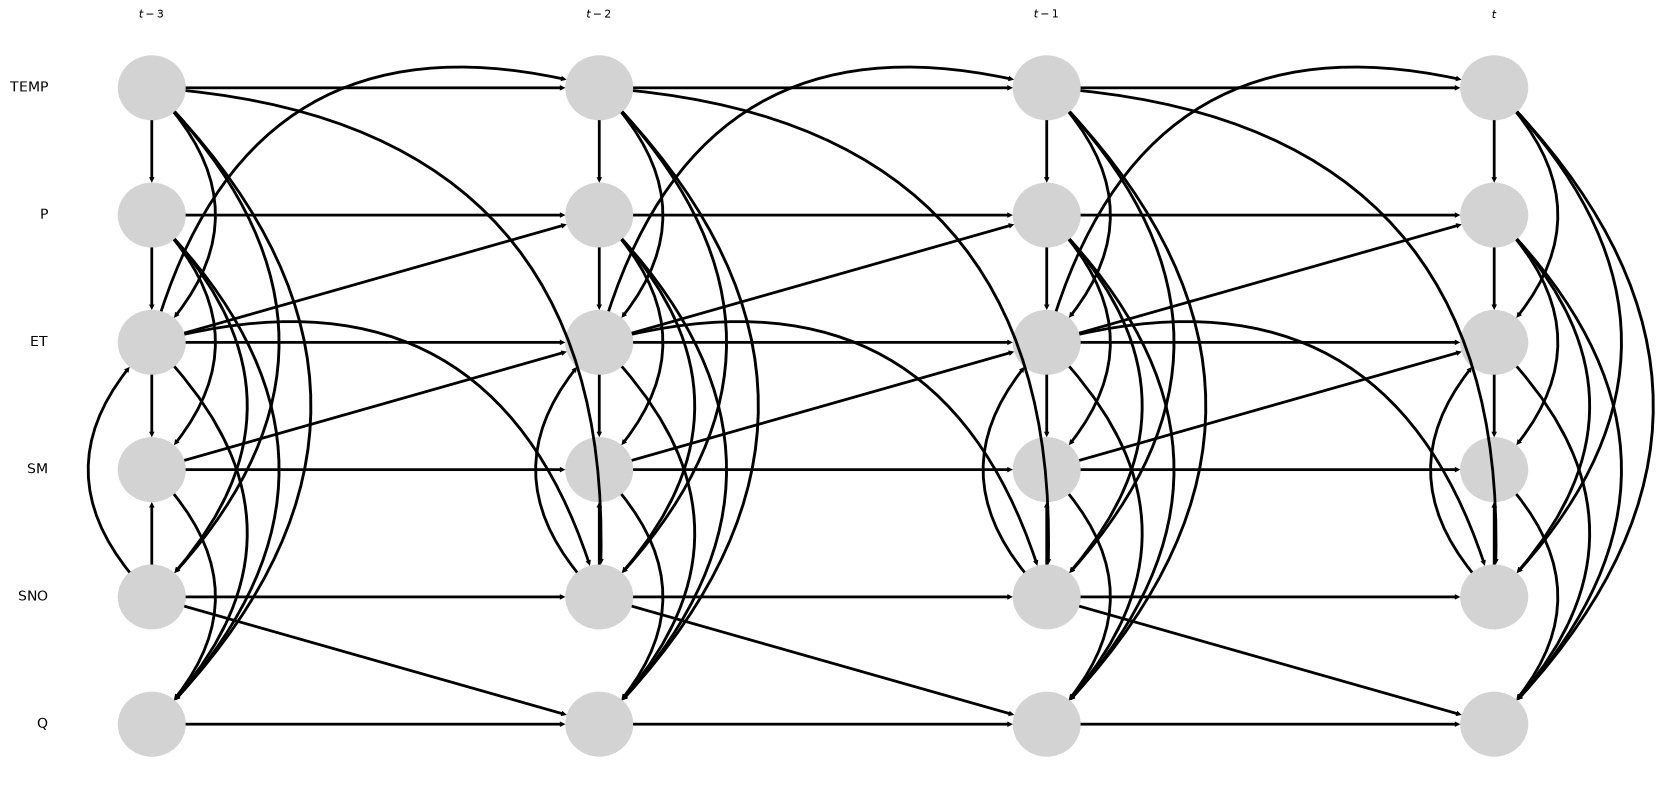

In [ ]:
tp.plot_time_series_graph(graph=graph, var_names=vars_df.columns, curved_radius=0.5, arrow_linewidth=2, figsize=(20, 10))

In [ ]:
CI_config_dict = {

    "graph": graph,

    (4,0) : {
        "X_dict": {
            (0, -2) : ["CMIknn", [(0, -3), (2, -3)]],
            (1, -1) : ["CMIknn", [(0, -1), (1, -2), (2, -2)]],
            (2, -2) : ["CMIknn", [(0, -2), (1, -3), (2, -3), (3, -3), (4, -2)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, -2) : ["CMIknn", [(0, -2), (4, -3)]],
            (5, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -1), (4, -2), (5, -2)]]
        },                   
        "Y_parents": [(0, 0), (0, -1), (1, 0), (2, -1), (4,-1)]
    },

    (5, 0) : {
        "X_dict": {
            (0, -1) : ["CMIknn", [(0, -2), (2, -2)]],
            (1, -1) : ["CMIknn", [(0, -1), (1, -2), (2, -2)]],
            (2, -1) : ["CMIknn", [(0, -1), (1, -1), (2, -2), (3, -2), (4, -1)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, 0)  : ["CMIknn", [(0, -1), (4, -1)]],
            (5, -2) : ["CMIknn", [(1, -2), (2, -2), (3, -2), (4, -3), (5, -3)]]

        },
        "Y_parents" : [(0,0), (1, 0), (2, 0), (3, 0), (4, -1), (5, -1)]
    }
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [ ]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name.split("_")[-1]] = pickle.load(f)

In [ ]:
draft_results["50.pkl"]

{'graph': array([[['', '-->', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['', '', '', ''],
         ['-->', '-->', '', ''],
         ['-->', '', '', '']],
 
        [['<--', '', '', ''],
         ['', '-->', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', '']],
 
        [['<--', '-->', '', ''],
         ['<--', '-->', '', ''],
         ['', '-->', '', ''],
         ['-->', '', '', ''],
         ['<--', '-->', '', ''],
         ['-->', '', '', '']],
 
        [['', '', '', ''],
         ['<--', '', '', ''],
         ['<--', '-->', '', ''],
         ['', '-->', '', ''],
         ['<--', '', '', ''],
         ['-->', '', '', '']],
 
        [['<--', '', '', ''],
         ['<--', '', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['', '-->', '', ''],
         ['', '-->', '', '']],
 
        [['<--', '', '', ''],
         ['<--', '', '', ''],
       

#### Third draft of graph

In [ ]:
# define tigramite graph and plot it 
draft = 3

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# variables are basinwise aggregates 

# temp 
graph[0, 0, 1] = "-->" # self causation
graph[0, 1, 0] = "-->" # impact on prec, if it gets hotter more water can be bound in air --> higher prec
graph[1, 0, 0] = "<--" # reverse
graph[0, 2, 0] = "-->" # higher temp, more et
graph[2, 0, 0] = "<--" # reverse
graph[0, 4, 0] = "-->" # impact on snowmelt
graph[4, 0, 0] = "<--" # reverse
graph[0, 4, 1] = "-->" # lagged because t can heat soil, which indirectly impacts snowmelt with a lag
graph[0, 4, 2] = "-->" # NEW: lag 2 (maybe heat lingers longer in soil)
graph[0, 5, 0] = "-->" # temperature increase can increase riverbed conductivity, result into more seepage, therefore affecting discharge https://doi.org/10.1029/94WR01968
graph[5, 0, 0] = "<--" # reverse
graph[0, 5, 1] = "<->" # hidden confounding because the conductivity from the study was explictely in the diurnal cylce


# prec 
graph[1, 1, 1] = "-->" # self causation
graph[1, 2, 0] = "-->" # impact on et, instant
graph[2, 1, 0] = "<--" # reverse
graph[1, 3, 0] = "-->" # impact on sm, instant where water hits the ground it infiltrates
graph[3, 1, 0] = "<--" # reverse
graph[1, 4, 0] = "-->" # prec falling on snow decreases albedo and snow depth, also increases liquid water content, which all contribute to faster melting https://doi.org/10.1002/hyp.15019
graph[4, 1, 0] = "<--" # reverse
graph[1, 4, 1] = "-->" # NEW: maybe water from yesterdays stays in snow
graph[1, 5, 0] = "-->" # impact on q, instant
graph[5, 1, 0] = "<--" # reverse

# et 
graph[2, 2, 1] = "-->" # self causation
graph[2, 0, 1] = "-->" # impact on temp, lagged as basinwise it takes some time to cool it
graph[2, 1, 1] = "-->" # lagged impact on prec
graph[2, 3, 0] = "-->" # impact on sm, lagged because puddles get et'd before soil
graph[3, 2, 0] = "<--" # impact on sm, instant over basin
graph[2, 4, 1] = "-->" # NEW: ET should impact snowmelt, as it consumes latent heat of the snowpack limiting melt, and condensation (positive part of this var)
                       # contributes latent heat, increasing melt https://doi.org/10.1016/j.jhydrol.2014.07.048 . its lagged to avoid cycle
graph[2, 5, 0] = "-->" # impact on q
graph[5, 2, 0] = "<--" # reverse

# sm  
graph[3, 3, 1] = "-->" # self causation
graph[3, 2, 1] = "-->" # impact on et, lagged because soil moistru
graph[3, 5, 0] = "-->" # impact on q
graph[5, 3, 0] = "<--" # reverse

# snowmelt 
graph[4, 4, 1] = "-->" # self causation
graph[4, 2, 0] = "-->" # impact on et, more liquid water --> more et
graph[2, 4, 0] = "<--" # reverse
graph[4, 3, 0] = "-->" # impact on sm, more liquid water can infiltrate
graph[3, 4, 0] = "<--" # reverse
graph[4, 5, 1] = "-->" # impact on qobs 

# q
graph[5, 5, 1] = "-->" # self causation


(<Figure size 3000x1000 with 1 Axes>, <Axes: >)

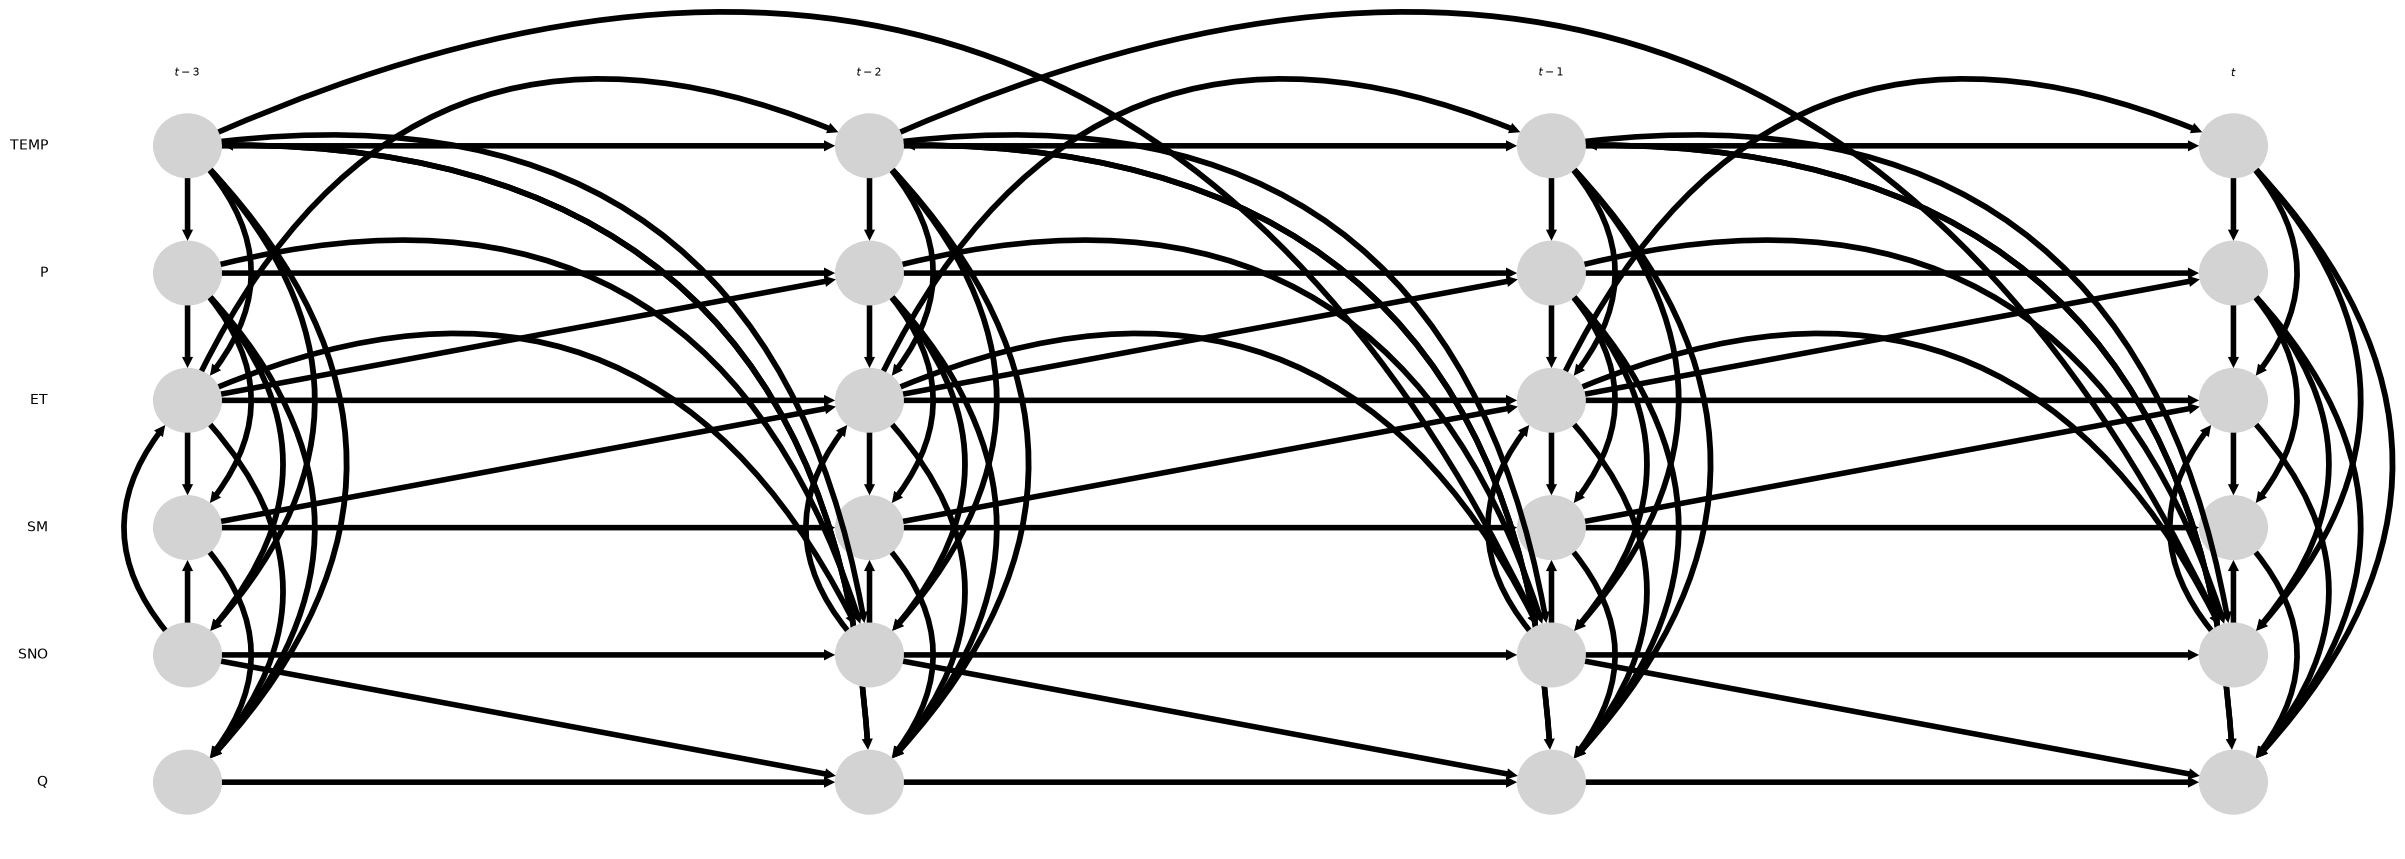

In [ ]:
tp.plot_time_series_graph(graph=graph, var_names=vars_df.columns, curved_radius=0.5, figsize=(30, 10))

In [ ]:
CI_config_dict = {

    "graph": graph,

    (4,0) : {
        "X_dict": {
            (0, -3) : ["CMIknn", [(0, -4), (2, -4)]],
            (1, -2) : ["CMIknn", [(0, -2), (1, -3), (2, -3)]],
            (2, -2) : ["CMIknn", [(0, -2), (1, -3), (2, -3), (3, -3), (4, -2)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, -2) : ["CMIknn", [(0, -2), (4, -3)]],
            (5, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -1), (4, -2), (5, -2)]]
        },                   
        "Y_parents": [(0, 0), (0, -1), (0, -2), (1, 0), (1, -1), (2, -1), (4,-1)]
    },

    (5, 0) : {
        "X_dict": {
            (0, -1) : ["CMIknn", [(0, -2), (2, -2)]],
            (1, -1) : ["CMIknn", [(0, -1), (1, -2), (2, -2)]],
            (2, -1) : ["CMIknn", [(0, -1), (1, -1), (2, -2), (3, -2), (4, -1)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, 0)  : ["CMIknn", [(0, -1), (4, -1)]],
            (5, -2) : ["CMIknn", [(1, -2), (2, -2), (3, -2), (4, -3), (5, -3)]]

        },
        "Y_parents" : [(0,0), (1, 0), (2, 0), (3, 0), (4, -1), (5, -1)]
    }
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [ ]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name.split("_")[-1]] = pickle.load(f)

In [ ]:
draft_results["50.pkl"]

{'graph': array([[['', '-->', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['', '', '', ''],
         ['-->', '-->', '-->', ''],
         ['-->', '<->', '', '']],
 
        [['<--', '', '', ''],
         ['', '-->', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['-->', '-->', '', ''],
         ['-->', '', '', '']],
 
        [['<--', '-->', '', ''],
         ['<--', '-->', '', ''],
         ['', '-->', '', ''],
         ['-->', '', '', ''],
         ['<--', '-->', '', ''],
         ['-->', '', '', '']],
 
        [['', '', '', ''],
         ['<--', '', '', ''],
         ['<--', '-->', '', ''],
         ['', '-->', '', ''],
         ['<--', '', '', ''],
         ['-->', '', '', '']],
 
        [['<--', '', '', ''],
         ['<--', '', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['', '-->', '', ''],
         ['', '-->', '', '']],
 
        [['<--', '', '', ''],
         ['<--', '', '', '']

#### Fourth draft of graph

In [ ]:
# define tigramite graph and plot it 
draft = 4

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# variables are basinwise aggregates 

# temp 
graph[0, 0, 1] = "-->" # self causation
graph[0, 1, 0] = "-->" # impact on prec, if it gets hotter more water can be bound in air --> higher prec
graph[1, 0, 0] = "<--" # reverse
graph[0, 2, 0] = "-->" # higher temp, more et
graph[2, 0, 0] = "<--" # reverse
graph[0, 4, 0] = "-->" # impact on snowmelt
graph[4, 0, 0] = "<--" # reverse
graph[0, 4, 1] = "-->" # lagged because t can heat soil, which indirectly impacts snowmelt with a lag
graph[0, 4, 2] = "-->" # lag 2 (maybe heat lingers longer in soil)
graph[0, 5, 0] = "-->" # temperature increase can increase riverbed conductivity, result into more seepage, therefore affecting discharge https://doi.org/10.1029/94WR01968
graph[5, 0, 0] = "<--" # reverse
graph[0, 5, 1] = "<->" # hidden confounding because the conductivity from the study was explictely in the diurnal cylce


# prec 
graph[1, 1, 1] = "-->" # self causation
graph[1, 2, 0] = "-->" # impact on et, instant
graph[2, 1, 0] = "<--" # reverse
graph[1, 3, 0] = "-->" # impact on sm, instant where water hits the ground it infiltrates
graph[3, 1, 0] = "<--" # reverse
graph[1, 4, 0] = "-->" # prec falling on snow decreases albedo and snow depth, also increases liquid water content, which all contribute to faster melting https://doi.org/10.1002/hyp.15019
graph[4, 1, 0] = "<--" # reverse
graph[1, 4, 1] = "-->" # maybe water from yesterdays stays in snow
graph[1, 4, 2] = "-->" # NEW: maybe water from two days ago stays in snow
graph[1, 5, 0] = "-->" # impact on q, instant
graph[5, 1, 0] = "<--" # reverse

# et 
graph[2, 2, 1] = "-->" # self causation
graph[2, 0, 1] = "-->" # impact on temp, lagged as basinwise it takes some time to cool it
graph[2, 1, 1] = "-->" # lagged impact on prec
graph[2, 3, 0] = "-->" # impact on sm, lagged because puddles get et'd before soil
graph[3, 2, 0] = "<--" # impact on sm, instant over basin
graph[2, 4, 1] = "-->" # NEW: ET should impact snowmelt, as it consumes latent heat of the snowpack limiting melt, and condensation (positive part of this var)
                       # contributes latent heat, increasing melt https://doi.org/10.1016/j.jhydrol.2014.07.048 . its lagged to avoid cycle
graph[2, 5, 0] = "-->" # impact on q
graph[5, 2, 0] = "<--" # reverse

# sm  
graph[3, 3, 1] = "-->" # self causation
graph[3, 2, 1] = "-->" # impact on et, lagged because soil moistru
graph[3, 5, 0] = "-->" # impact on q
graph[5, 3, 0] = "<--" # reverse

# snowmelt 
graph[4, 4, 1] = "-->" # self causation
graph[4, 2, 0] = "-->" # impact on et, more liquid water --> more et
graph[2, 4, 0] = "<--" # reverse
graph[4, 3, 0] = "-->" # impact on sm, more liquid water can infiltrate
graph[3, 4, 0] = "<--" # reverse
graph[4, 5, 1] = "-->" # impact on qobs 

# q
graph[5, 5, 1] = "-->" # self causation


(<Figure size 3000x1000 with 1 Axes>, <Axes: >)

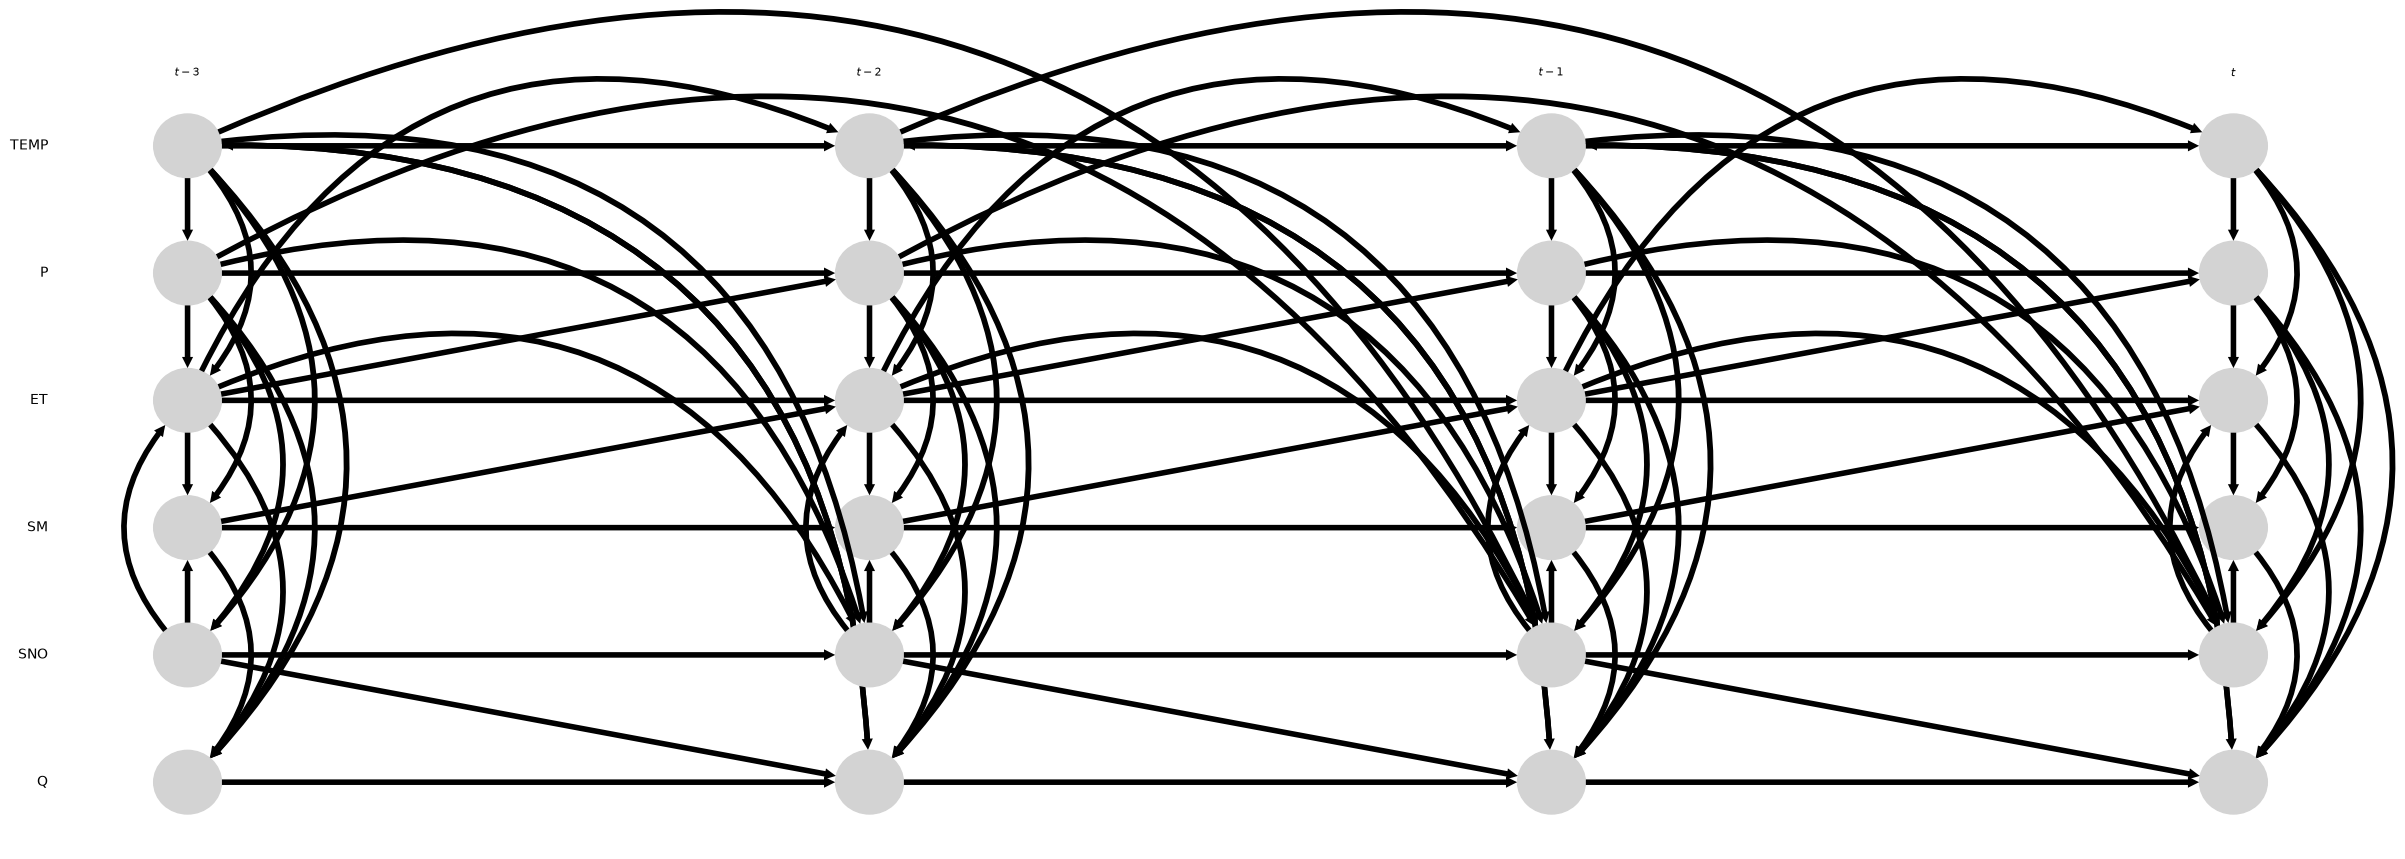

In [ ]:
tp.plot_time_series_graph(graph=graph, var_names=vars_df.columns, curved_radius=0.5, figsize=(30, 10))

In [ ]:
CI_config_dict = {

    "graph": graph,

    (4,0) : {
        "X_dict": {
            (1, -3) : ["CMIknn", [(0, -3), (1, -4), (2, -4)]],
        },                   
        "Y_parents": [(0, 0), (0, -1), (0, -2), (1, 0), (1, -1), (1, -2), (2, -1), (4,-1)]
    }
}

# Test only altered edge

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [ ]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name.split("_")[-1]] = pickle.load(f)

In [ ]:
draft_results["50.pkl"]

{'graph': array([[['', '-->', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['', '', '', ''],
         ['-->', '-->', '-->', ''],
         ['-->', '<->', '', '']],
 
        [['<--', '', '', ''],
         ['', '-->', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['-->', '-->', '', ''],
         ['-->', '', '', '']],
 
        [['<--', '-->', '', ''],
         ['<--', '-->', '', ''],
         ['', '-->', '', ''],
         ['-->', '', '', ''],
         ['<--', '-->', '', ''],
         ['-->', '', '', '']],
 
        [['', '', '', ''],
         ['<--', '', '', ''],
         ['<--', '-->', '', ''],
         ['', '-->', '', ''],
         ['<--', '', '', ''],
         ['-->', '', '', '']],
 
        [['<--', '', '', ''],
         ['<--', '', '', ''],
         ['-->', '', '', ''],
         ['-->', '', '', ''],
         ['', '-->', '', ''],
         ['', '-->', '', '']],
 
        [['<--', '', '', ''],
         ['<--', '', '', '']

## 2. Causal Effect Estimation

In [ ]:
X = [(4, -1)]
Y = [(5, 0)]
causal_effects = CausalEffects(graph=graph, graph_type="stationary_dag", X=X, Y=Y, check_SM_overlap=True, verbosity=1)


##
## Initializing CausalEffects class
##

Input:

graph_type = stationary_dag
X = [(4, -1)]
Y = [(5, 0)]
S = []
M = [(np.int64(2), np.int64(-1)), (np.int64(4), np.int64(0)), (np.int64(3), np.int64(-1)), (np.int64(0), np.int64(0)), (np.int64(5), np.int64(-1)), (np.int64(2), np.int64(0)), (np.int64(3), np.int64(0)), (np.int64(1), np.int64(0))]





In [ ]:
opt = causal_effects.get_optimal_set()
print("Oset = ", [(vars_df.columns[v[0]], v[1]) for v in opt])

Oset =  [('ET', np.int64(-2)), ('TEMP', np.int64(-3)), ('SM', np.int64(-2)), ('ET', np.int64(-3)), ('Q', np.int64(-2)), ('P', np.int64(-1)), ('TEMP', np.int64(-1)), ('SNO', np.int64(-2)), ('TEMP', np.int64(-2))]


(<Figure size 800x600 with 1 Axes>, <Axes: >)

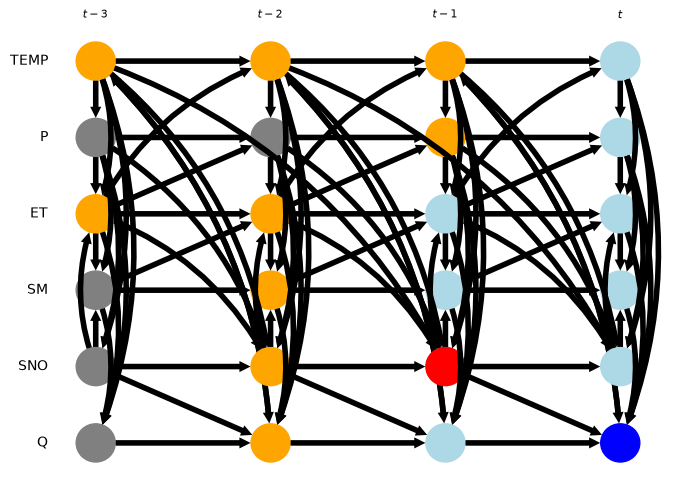

In [ ]:
special_nodes = {}
for node in causal_effects.X:
    special_nodes[node] = 'red'
for node in causal_effects.Y:
    special_nodes[node] = 'blue'
for node in opt:
    special_nodes[node] = 'orange'
for node in causal_effects.M:
    special_nodes[node] = 'lightblue'

tp.plot_time_series_graph(graph = graph,
        var_names=vars_df.columns, 
#         save_name='Example.pdf',
        figsize = (8, 6),
        special_nodes=special_nodes,
        )

In [ ]:
optimality = causal_effects.check_optimality()
print("(Graph, X, Y, S) fulfills optimality: ", optimality)

Optimality = True with cond_0 = False, cond_I = True, cond_II = True
(Graph, X, Y, S) fulfills optimality:  True


In [ ]:
causal_effects.fit_total_effect(
    dataframe=vars_tg,
    estimator=RandomForestRegressor(),
    adjustment_set="optimal",
)

/home/wuhlmann/CS/causal_inference/snow_causal_inference/.pixi/envs/default/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
causal_effects.model.fit_results["model"]

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [ ]:
vars_df.SNO.describe()

count    13513.000000
mean         1.895453
std          4.760188
min          0.000000
25%          0.000000
50%          0.000000
75%          0.330000
max         32.200000
Name: SNO, dtype: float64

In [ ]:
intervention_data = 2*np.ones((1, 1))
y1 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y1 = ",y1)

intervention_data = 13.*np.ones((1, 1))
y2 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y2 = ",y2)

y1 =  [5.29236134]
y2 =  [6.38177431]


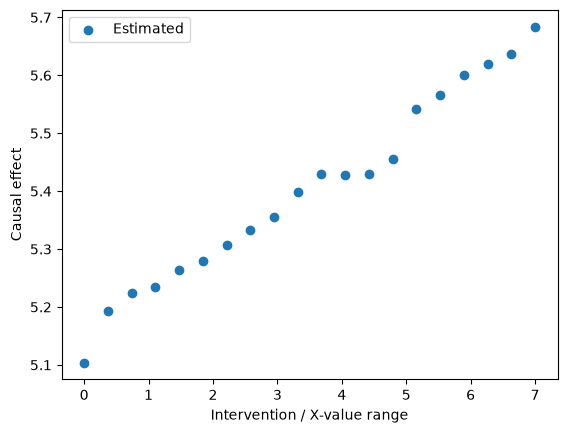

In [ ]:
intervention_data = np.linspace(0, 7, 20).reshape(20, 1)
estimated_causal_effects = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
plt.scatter(intervention_data[:,0], estimated_causal_effects, label="Estimated")
plt.xlabel('Intervention / X-value range')
plt.ylabel('Causal effect')
plt.legend()
plt.show()

### Archive

In [ ]:
import numpy as np
import pandas as pd
from itertools import product
 
from tigramite.independence_tests.oracle_conditional_independence import OracleCI
from tigramite import data_processing as pp
 
 
def get_parents(graph, tau_max, var, lag):
    """Eltern von Knoten (var, lag) im stationären Graphen."""
    N = graph.shape[0]
    parents = []
    for i in range(N):
        for tau in range(0, tau_max + 1):
            if graph[i, var, tau] == "-->":
                parents.append((i, lag - tau))
    return parents
 
 
def edge_exists(graph, tau_max, i, li, j, lj):
    """Gibt es eine direkte Kante zwischen (i, li) und (j, lj)?"""
    diff = lj - li
    if 0 <= diff <= tau_max and graph[i, j, diff] == "-->":
        return True
    diff2 = li - lj
    if 0 <= diff2 <= tau_max and graph[j, i, diff2] == "-->":
        return True
    return False
 
 
def check_markov(graph, vars_df, tau_max, cond_ind_test, window=None, alpha=0.05, verbosity=0):
    """
    Leitet für alle nicht-adjazenten Paare (X, Y=(j,0)) die
    Eltern-basierte Trennmenge ab, bestätigt sie mit OracleCI und
    testet sie anschließend mit test auf den echten Daten.
 
    window : wie weit X in die Vergangenheit zurückreicht (Default: 2*tau_max)
    alpha  : Signifikanzniveau für den echten CI-Test
 
    Returns
    -------
    results : pandas.DataFrame mit einer Zeile pro getestetem Tripel
    """
    N = graph.shape[0]
    var_names = list(vars_df.columns)
    if window is None:
        window = 2 * tau_max if tau_max > 0 else 1
 
    oracle = OracleCI(graph=graph)
    dataframe = pp.DataFrame(vars_df.values, var_names=var_names)
    test = cond_ind_test
    test.set_dataframe(dataframe)
 
    rows = []
    for j in range(N):  # Zielvariable Y
        Y = [(j, 0)]
        Pa_Y = get_parents(graph, tau_max, j, 0)
        print(Y)
 
        for i, tau in product(range(N), range(0, window + 1)):
            X_node = (i, -tau)
            if X_node == (j, 0):
                continue
            if edge_exists(graph, tau_max, i, -tau, j, 0):
                continue  # direkt verbunden -> keine Implikation zu testen
 
            X = [X_node]
            Pa_X = get_parents(graph, tau_max, i, -tau)
            Z = sorted(set(Pa_X) | set(Pa_Y) - {X_node, (j, 0)})
 
            # 1) Gegenprüfung: separiert Z laut Graph tatsächlich X und Y?
            max_abs_lag = max([abs(l) for _, l in [X_node, (j, 0)] + Z] + [tau_max])
            _, oracle_pval = oracle.run_test(X=X, Y=Y, Z=Z, tau_max=max_abs_lag)
            if oracle_pval != 1.0:
                continue  # keine gültige Implikation mit dieser Z-Wahl
 
            # 2) Echter Test auf den Daten
            val, pval = test.run_test(X=X, Y=Y, Z=Z, tau_max=max_abs_lag)
 
            rows.append({
                "X": f"{var_names[i]}(t-{tau})" if tau else f"{var_names[i]}(t)",
                "Y": f"{var_names[j]}(t)",
                "|Z|": len(Z),
                "val": round(val, 3),
                "pval": round(pval, 4),
                "verletzt (p<alpha)": pval < alpha,
            })
 
            if verbosity:
                print(f"{var_names[i]}(t-{tau}) _||_ {var_names[j]}(t) | "
                      f"{len(Z)} Vars  ->  pval={pval:.4f}")
 
    results = pd.DataFrame(rows)
    return results
  

In [ ]:
#res = check_markov(graph=graph, vars_df=vars_df.dropna(), cond_ind_test=ParCorrWLS(), tau_max=1, verbosity=1)

In [ ]:
#res[res["verletzt (p<alpha)"]]